# Homework 2: Functions, Merging & Visualization

This assignment synthesizes concepts from the Week 4 practice notebooks. Use the table below as a reference for where each function was introduced.

### **Concept Reference Map**

| Category | Concept / Function | Original Reference Notebook |
| :--- | :--- | :--- |
| **Data Exploration** | `info()`, `columns`, `unique()`, `head()` | `1-visualization_basics.ipynb` |
| **Statistics** | `describe()`, `mean()`, `pct_change()` | `1-visualization_basics.ipynb` |
| **Manipulation** | `rename()`, `query()`, `drop()`, `set_index()` | `1-visualization_basics.ipynb` / `2-merging_practice.ipynb` |
| **Aggregation** | `groupby()` | `1-visualization_basics.ipynb` |
| **Time Series** | `pd.to_datetime()`, `PeriodIndex` | `2-merging_practice.ipynb` |
| **Merging** | `pd.merge()`, `pd.concat()` | `2-merging_practice.ipynb` |
| **Visualization** | `plot()`, `scatter()`, `barh()` | `1-visualization_basics.ipynb` |

---

## A. Importing Data

Run the cell below to load the WorldBank API function and download population and GDP data for G7 countries.

In [2]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

def get_wb_data(indicator, countries_list, start_year, end_year):
    country_str = ';'.join(countries_list)
    url = f'https://api.worldbank.org/v2/country/{country_str}/indicator/{indicator}?date={start_year}:{end_year}&format=json&per_page=1000'
    response = requests.get(url)
    data = response.json()[1]
    df = pd.json_normalize(data)
    return df[['countryiso3code', 'date', 'value']]

## A.1 Show info

In [3]:
G7 = ['CAN', 'FRA', 'DEU', 'ITA', 'JPN', 'GBR', 'USA']

In [4]:
inflation_df = get_wb_data('FP.CPI.TOTL.ZG', G7, 2000, 2022)
inflation_df.head(5)

,countryiso3code,date,value
0,CAN,2022,6.802801
1,CAN,2021,3.395193
2,CAN,2020,0.717000
3,CAN,2019,1.949269
4,CAN,2018,2.268226


In [5]:
gdp_df = get_wb_data('NY.GDP.MKTP.CD', G7, 2000, 2022)
gdp_df.head(5)

,countryiso3code,date,value
0,CAN,2022,2.190411e+12
1,CAN,2021,2.022379e+12
2,CAN,2020,1.655685e+12
3,CAN,2019,1.743725e+12
4,CAN,2018,1.725329e+12


## A.2 Show column names


In [6]:
columns = [['countryiso3code', 'date', 'value']]
inflation_df.head(5)

,countryiso3code,date,value
0,CAN,2022,6.802801
1,CAN,2021,3.395193
2,CAN,2020,0.717000
3,CAN,2019,1.949269
4,CAN,2018,2.268226


## A.3 Show unique countries

In [7]:
inflation_df = inflation_df.query("countryiso3code == 'USA'")
inflation_df.head(5)

,countryiso3code,date,value
138,USA,2022,8.002800
139,USA,2021,4.697859
140,USA,2020,1.233584
141,USA,2019,1.812210
142,USA,2018,2.442583


In [8]:
inflation_df.tail(2)

,countryiso3code,date,value
159,USA,2001,2.826171
160,USA,2000,3.376857


# 1. Show GDP Growth for Japan using above data

## 1.A Rename column for country and value

In [9]:
rename_dictionary = {"countryiso3code": "country", "value": "inflation"}
inflation_df.rename(columns=rename_dictionary, inplace=True)
inflation_df.head(2)

,country,date,inflation
138,USA,2022,8.002800
139,USA,2021,4.697859


In [10]:
rename_dictionary = {"countryiso3code": "country", "value": "GDP"}
gdp_df.rename(columns=rename_dictionary, inplace=True)
gdp_df.head(2)

,country,date,GDP
0,CAN,2022,2.190411e+12
1,CAN,2021,2.022379e+12


## 1.1 Create new data with only Japan

In [11]:
df_jp = gdp_df.query("country == 'JPN'")
df_jp.head(5)

,country,date,GDP
115,JPN,2022,4.262463e+12
116,JPN,2021,5.039148e+12
117,JPN,2020,5.054068e+12
118,JPN,2019,5.117994e+12
119,JPN,2018,5.040881e+12


## 1.2 Set index as date, sort index, and drop country column

In [12]:
df_jp = df_jp.set_index('date')
df_jp.head(2)

,country,GDP
date,,
2022,JPN,4.262463e+12
2021,JPN,5.039148e+12


In [13]:
# DROP country column
df_jp=df_jp.drop(columns=['country'])
df_jp.head(2)

,GDP
date,
2022,4.262463e+12
2021,5.039148e+12


In [14]:
df_jp = df_jp.sort_index()

## 1.3 Plot

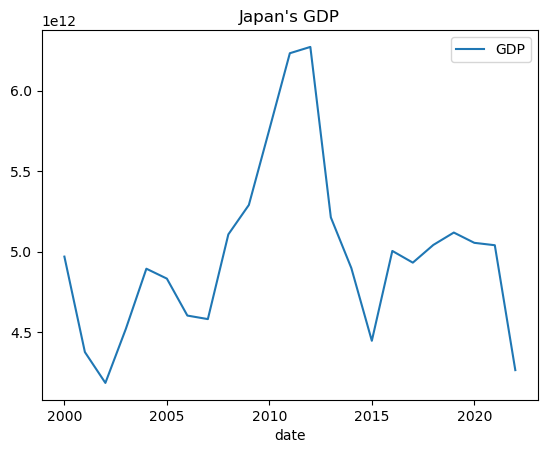

In [15]:
df_jp.plot()
plt.title("Japan's GDP");

<Axes: >

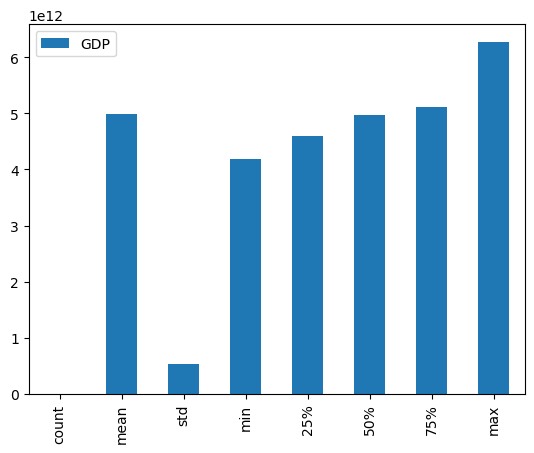

In [16]:
df_jp.describe().plot(kind='bar')


# 2. Merging Data
## 2.A Importing data

In [17]:
df_gdp = pd.read_csv("../../../data/hw/hw_2/eichengreen_1.csv")
df_gdp.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
0,BR,1997,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.000000,9.750000,6.0,0.020075,NaN
1,BR,1998,Brunei,62020.909406,19793.601111,NaN,NaN,3.000000,3.583333,7.583333,6.0,0.039924,NaN


In [18]:
df_govt_bond = pd.read_csv("../../../data/hw/hw_2/eichengreen_2.csv")
df_govt_bond.head(2)

,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997,Brunei,11.062,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
1,BR,1998,Brunei,14.424,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


## 2.1 Filter one country

In [19]:
df_govt_bond.economy.unique()
df_gdp_vn = df_gdp.query("economy == 'VN'")

In [20]:
#MAKE SURE YOU query df_govt_bond
df_govt_bond_vn = df_govt_bond.query("economy == 'VN'")
df_gdp_vn.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
299,VN,1997,Vietnam,1709.896773,131889.833685,5.904167,19.848841,2.0,2.416667,6.583333,5.0,0.013462,NaN
300,VN,1998,Vietnam,1805.815779,141062.581723,5.170000,20.123863,2.0,2.000000,5.166667,5.0,0.024974,NaN


In [21]:
df_gdp_vn.tail(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
320,VN,2018,Vietnam,7447.814334,711567.123362,2.720389,133.135982,2.0,2.375,8.083333,4.0,0.001244,NaN
321,VN,2019,Vietnam,NaN,NaN,NaN,NaN,2.0,2.500,8.500000,4.0,0.001129,NaN


In [22]:
#MAKE SURE YOU GET GDP Data df_gdp
df_gdp_vn = df_gdp.query("economy == 'VN'")
df_gdp_vn.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
299,VN,1997,Vietnam,1709.896773,131889.833685,5.904167,19.848841,2.0,2.416667,6.583333,5.0,0.013462,NaN
300,VN,1998,Vietnam,1805.815779,141062.581723,5.170000,20.123863,2.0,2.000000,5.166667,5.0,0.024974,NaN


## 2.2 Filter gdp_pc_pp and set date as index

In [47]:
df_govt_bond_vn = df_govt_bond.query("economy == 'VN'")
df_gdp_vn.head(2)

,gdp_pc_ppp
date,
1997,1709.896773
1998,1805.815779


## 2.3 Merge data

In [46]:
# NOTE I sorted index and drop na
df_merge = pd.concat([df_gdp_vn, df_govt_bond_vn], axis=1).sort_index().dropna()
df_merge.head(5)

,gdp_pc_ppp,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled


## 2.4 Convert to datetime

In [45]:
# No code changes needed
df_merge.index = pd.to_datetime(df_merge.index, format = "%Y")
df_merge.head(2)

,gdp_pc_ppp,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled


## 2.4 Plot net_borrow

Text(0, 0.5, '% GDP')

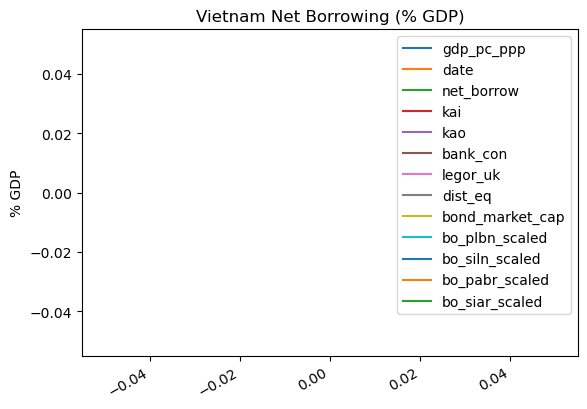

In [26]:
# Your code here
df_merge.plot()
plt.title("Vietnam Net Borrowing (% GDP)")
plt.ylabel("% GDP")

# 3. Functions

## 3.A Import Data

In [27]:
df_gdp = pd.read_csv("../../../data/hw/hw_2/eichengreen_1.csv")
df_govt_bond = pd.read_csv("../../../data/hw/hw_2/eichengreen_2.csv")
df_merge_all = pd.concat([df_gdp, df_govt_bond], axis = 'columns')
df_merge_all.columns

Index(['economy', 'date', 'country', 'gdp_pc_ppp', 'gdp_ppp', 'ir_spread',
       'cred_priv_sec', 'bureaucracy_qual', 'corruption', 'investment_profile',
       'law_order', 'exchange_rate', 'sd_interbank', 'economy', 'date',
       'country', 'net_borrow', 'kai', 'kao', 'bank_con', 'legor_uk',
       'dist_eq', 'bond_market_cap', 'bo_plbn_scaled', 'bo_siln_scaled',
       'bo_pabr_scaled', 'bo_siar_scaled'],
      dtype='object')

In [28]:
df_merge_all = pd.merge(df_gdp, df_govt_bond, on=['economy', 'date', 'country'])
df_merge_all.columns

Index(['economy', 'date', 'country', 'gdp_pc_ppp', 'gdp_ppp', 'ir_spread',
       'cred_priv_sec', 'bureaucracy_qual', 'corruption', 'investment_profile',
       'law_order', 'exchange_rate', 'sd_interbank', 'net_borrow', 'kai',
       'kao', 'bank_con', 'legor_uk', 'dist_eq', 'bond_market_cap',
       'bo_plbn_scaled', 'bo_siln_scaled', 'bo_pabr_scaled', 'bo_siar_scaled'],
      dtype='object')

## 3.1 Create function to conver to datetime

In [29]:
def convert_date(df):
    df_copy = df.copy()
    df_copy['date'] = pd.to_datetime(df_copy['date'], format="%Y")
    return df_copy

In [30]:
df_merge_all.head(1)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,...,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.0,9.75,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


In [31]:
df_merge_all_converted = convert_date(df_merge_all)
df_merge_all_converted.head(1)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,...,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997-01-01,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.0,9.75,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


## 3.2 Rename column function

/var/folders/b_/74kc96yj6vq9w00n4bccr7th0000gn/T/ipykernel_70430/1406978270.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  plt.scatter(df_plot['gdp_pc_ppp'].pct_change(1), df_plot['net_borrow'])


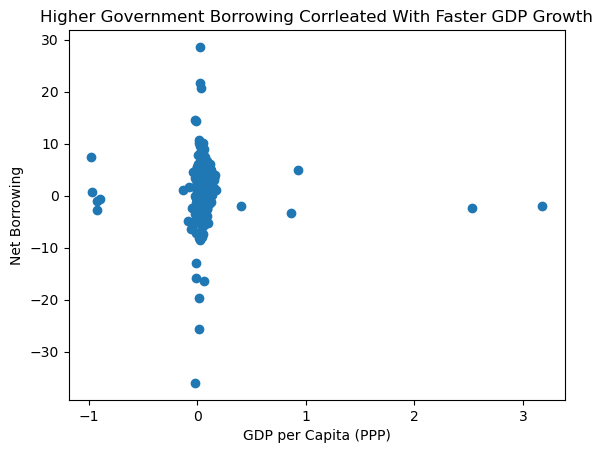

In [32]:
def plot_scatter(x_title, y_title, main_title):
    df_plot = df_merge_all_converted
    
    # Define the columns for x and y
    plt.scatter(df_plot['gdp_pc_ppp'].pct_change(1), df_plot['net_borrow'])
    
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(main_title)

# Note corrleation does not equal causation :)
plot_scatter('GDP per Capita (PPP)', 'Net Borrowing', 'Higher Government Borrowing Corrleated With Faster GDP Growth')